### Example of using utils functions

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = {
    "CaseID": [1, 1, 1, 2, 2],
    "Activity": ["Ricezione", "Valutazione", "Approvazione", "Ricezione", "Valutazione"],
    "time:timestamp": ["2023/10/01 10:00:00", "2023/10/01 11:00:00", "2023/10/01 12:00:00", "2024/10/01 12:00:00", "2024/11/01 12:00:00"],
    "org:resource": ["Alice", "Bob", "Alice", "Alice", "Bob"],
    "case:AMOUNT_REQ": [5000, 5000, 5000, 7000, 7000]
}
dataset = pd.DataFrame(data)

dataset

,CaseID,Activity,time:timestamp,org:resource,case:AMOUNT_REQ
0,1,Ricezione,2023/10/01 10:00:00,Alice,5000
1,1,Valutazione,2023/10/01 11:00:00,Bob,5000
2,1,Approvazione,2023/10/01 12:00:00,Alice,5000
3,2,Ricezione,2024/10/01 12:00:00,Alice,7000
4,2,Valutazione,2024/11/01 12:00:00,Bob,7000


In [4]:
# Extracting the trace for CaseID 1
trace = dataset[dataset["CaseID"] == 1]
trace

,CaseID,Activity,time:timestamp,org:resource,case:AMOUNT_REQ
0,1,Ricezione,2023/10/01 10:00:00,Alice,5000
1,1,Valutazione,2023/10/01 11:00:00,Bob,5000
2,1,Approvazione,2023/10/01 12:00:00,Alice,5000


#### Creation of the nodes

In [4]:
prefix_len = len(trace)
prefix_len

3

In [5]:
from data.utils import get_node_features


In [6]:
node_features = get_node_features(dataset, trace) # it returns me a dictionary with tensors inside.
node_features

{'Activity': tensor([[0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.]]),
 'time:timestamp': tensor([[1.6961e+09],
         [1.6962e+09],
         [1.6962e+09]]),
 'org:resource': tensor([[1., 0.],
         [0., 1.],
         [1., 0.]]),
 'case:AMOUNT_REQ': tensor([[5000.]])}

In [7]:
for key, value in node_features.items():
    print(key, node_features[key].shape)

Activity torch.Size([3, 3])
time:timestamp torch.Size([3, 1])
org:resource torch.Size([3, 2])
case:AMOUNT_REQ torch.Size([1, 1])


We can see that the function used the One-Hot Encoder and the time converter, it gave me a dictionary with key-value pairs. The key are the attributes of the event of the same trace.

#### Creation of the edges
How these nodes are connected to each other

In [8]:
from data.utils import compute_edges_indexs, compute_edges_features
import torch

In [9]:
edges_indexes = compute_edges_indexs(node_features, prefix_len)
edges_indexes

{('Activity', 'followed_by', 'Activity'): [[0, 1], [0, 2], [1, 2]],
 ('Activity', 'related_to', 'time:timestamp'): [[0, 0], [1, 1], [2, 2]],
 ('Activity', 'related_to', 'org:resource'): [[0, 0], [1, 1], [2, 2]],
 ('Activity', 'related_to', 'case:AMOUNT_REQ'): [[0, 0], [1, 0], [2, 0]],
 ('time:timestamp', 'related_to', 'time:timestamp'): [[0, 1], [0, 2], [1, 2]],
 ('org:resource', 'related_to', 'org:resource'): [[0, 1], [0, 2], [1, 2]]}

In [10]:
for key, value in edges_indexes.items():
    print(key, type(value))
    print(len(value))

('Activity', 'followed_by', 'Activity') <class 'list'>
3
('Activity', 'related_to', 'time:timestamp') <class 'list'>
3
('Activity', 'related_to', 'org:resource') <class 'list'>
3
('Activity', 'related_to', 'case:AMOUNT_REQ') <class 'list'>
3
('time:timestamp', 'related_to', 'time:timestamp') <class 'list'>
3
('org:resource', 'related_to', 'org:resource') <class 'list'>
3


In [11]:
# edge features is a list of tensors (one for every edge)
edge_features = compute_edges_features(node_features, edges_indexes)
edge_features

{('Activity', 'followed_by', 'Activity'): [tensor([ 0., -1.,  1.,  1.]),
  tensor([ 1., -1.,  0.,  2.]),
  tensor([ 1.,  0., -1.,  1.])],
 ('time:timestamp',
  'related_to',
  'time:timestamp'): [tensor([3.5840e+03, 1.0000e+00]), tensor([7.1680e+03, 2.0000e+00]), tensor([3.5840e+03, 1.0000e+00])],
 ('org:resource', 'related_to', 'org:resource'): [tensor([-1.,  1.,  1.]),
  tensor([0., 0., 2.]),
  tensor([ 1., -1.,  1.])]}

In [12]:
from torch_geometric.data import HeteroData
from torch import tensor
data = HeteroData()

In [13]:
# insert the nodesprint(edges_indexes[('Activity', 'followed_by', 'Activity')].shape)
for key, value in node_features.items():
    data[key].x = value
data

HeteroData(
  Activity={ x=[3, 3] },
  time:timestamp={ x=[3, 1] },
  org:resource={ x=[3, 2] },
  case:AMOUNT_REQ={ x=[1, 1] }
)

In [14]:
from torch import tensor, long


In [15]:
for key, value in edges_indexes.items():
    data[key].edge_index = torch.tensor(value, dtype=torch.long).t()

    if key in edge_features and len(edge_features[key]) > 0:
        feature_tensor = torch.stack(edge_features[key]).to(torch.float32)

        data[key].edge_attr = feature_tensor

print(data)

HeteroData(
  Activity={ x=[3, 3] },
  time:timestamp={ x=[3, 1] },
  org:resource={ x=[3, 2] },
  case:AMOUNT_REQ={ x=[1, 1] },
  (Activity, followed_by, Activity)={
    edge_index=[2, 3],
    edge_attr=[3, 4],
  },
  (Activity, related_to, time:timestamp)={ edge_index=[2, 3] },
  (Activity, related_to, org:resource)={ edge_index=[2, 3] },
  (Activity, related_to, case:AMOUNT_REQ)={ edge_index=[2, 3] },
  (time:timestamp, related_to, time:timestamp)={
    edge_index=[2, 3],
    edge_attr=[3, 2],
  },
  (org:resource, related_to, org:resource)={
    edge_index=[2, 3],
    edge_attr=[3, 3],
  }
)


In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from data.utils import visualize_heterogeneous_graph

In [17]:
import importlib
import data.utils as utils
importlib.reload(utils)

<module 'data.utils' from '/home/danbi/Projects/SANAGRAPH/data/utils.py'>

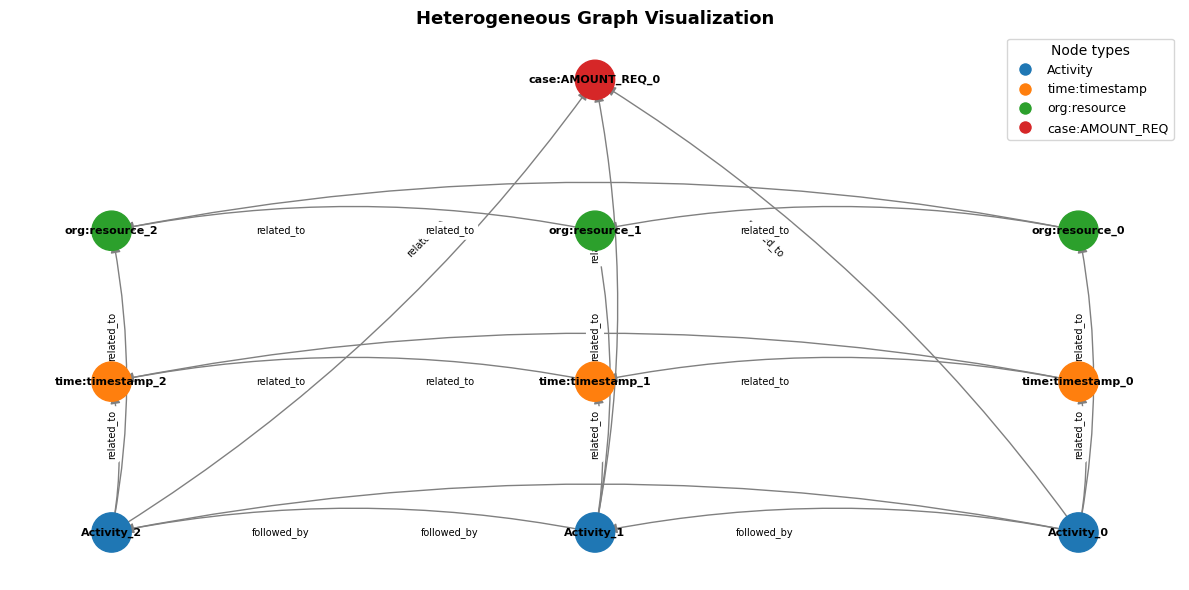

In [18]:
visualize_heterogeneous_graph(data)